In [27]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Reproducibility
np.random.seed(42)

# Global style — makes all plots look clean
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

In [28]:
# ── Synthetic Dataset ────────────────────────────────────────────────────────
# Simulates a company's sales + HR data over 3 years

N = 300  # number of employee records

departments  = ['Sales', 'Engineering', 'Marketing', 'HR', 'Finance']
regions      = ['North', 'South', 'East', 'West']
genders      = ['Male', 'Female']

df = pd.DataFrame({
    # Categorical columns
    'Department' : np.random.choice(departments, N),
    'Region'     : np.random.choice(regions, N),
    'Gender'     : np.random.choice(genders, N),
    'Year'       : np.random.choice([2022, 2023, 2024], N),

    # Numeric columns
    'Age'        : np.random.randint(22, 58, N),
    'Salary'     : np.random.normal(70000, 15000, N).round(0),
    'Experience' : np.random.randint(1, 20, N),
    'Performance': np.random.uniform(1, 10, N).round(1),   # score out of 10
    'Sales_Units': np.random.poisson(lam=50, size=N),
    'Satisfaction': np.random.choice([1,2,3,4,5], N,        # Likert scale
                        p=[0.05, 0.10, 0.25, 0.35, 0.25]),
    'Training_Hrs': np.random.exponential(scale=20, size=N).round(1),
})

# Add a correlated column: higher experience → higher salary (roughly)
df['Salary'] = df['Salary'] + df['Experience'] * 1200

# Monthly time-series data for line/area charts
months = pd.date_range('2022-01', periods=36, freq='MS')
ts = pd.DataFrame({
    'Month'   : months,
    'Revenue' : np.cumsum(np.random.normal(5000, 800, 36)) + 50000,
    'Expenses': np.cumsum(np.random.normal(3000, 600, 36)) + 30000,
})

print(df.shape)
df.head(3)

(300, 11)


,Department,Region,Gender,Year,Age,Salary,Experience,Performance,Sales_Units,Satisfaction,Training_Hrs
0,HR,North,Male,2023,46,88406.0,12,8.1,58,5,11.2
1,Finance,West,Female,2024,39,99017.0,15,8.8,47,1,7.4
2,Marketing,North,Female,2024,29,83750.0,15,6.5,55,4,13.2


---
## 1. Bar Chart
### 📌 Use when: Comparing counts or aggregates across **categories**

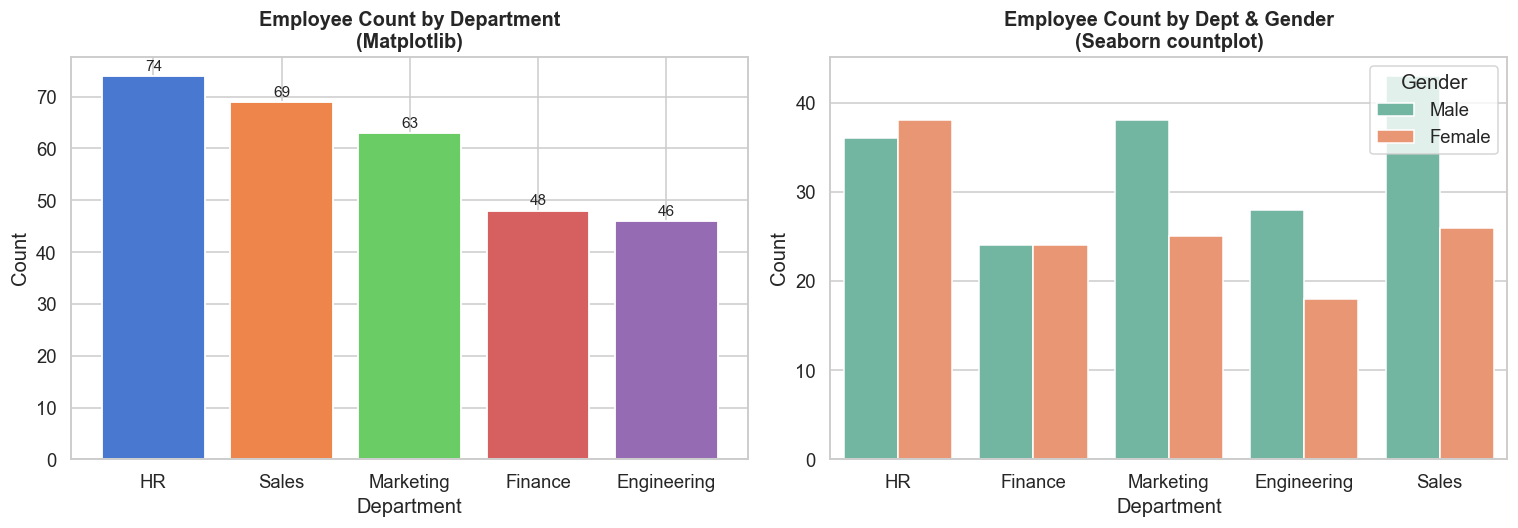

In [29]:
# ── 1a. Matplotlib — Vertical Bar Chart ─────────────────────────────────────
dept_count = df['Department'].value_counts()  # count employees per department

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Matplotlib bar ---
axes[0].bar(
    dept_count.index,          # x-axis: department names
    dept_count.values,         # y-axis: counts
    color=sns.color_palette('muted', len(dept_count)),  # distinct colors
    edgecolor='white', linewidth=1.2
)
axes[0].set_title('Employee Count by Department\n(Matplotlib)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Count')

# Add value labels on top of each bar
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,  # center of bar
        bar.get_height() + 0.5,              # just above bar
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=10
    )

# --- Right: Seaborn countplot (bar chart for counts) ---
sns.countplot(
    data=df,
    x='Department',
    hue='Gender',              # adds color grouping by Gender
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Employee Count by Dept & Gender\n(Seaborn countplot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Count')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

---
## 2. Horizontal Bar Chart
### 📌 Use when: Category labels are long OR you want to rank items clearly

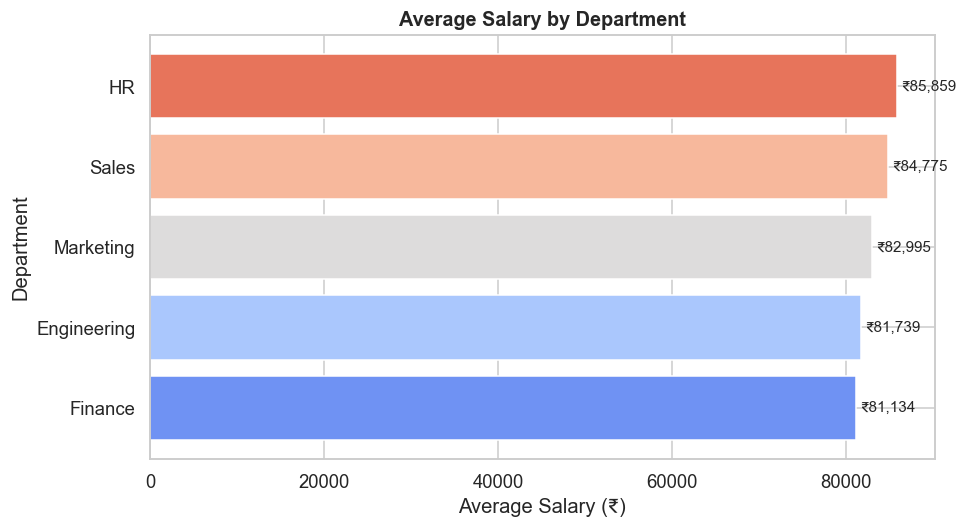

In [30]:
# Average salary per department — sorted for readability
avg_salary = df.groupby('Department')['Salary'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))

# barh → horizontal bars
bars = ax.barh(
    avg_salary.index,
    avg_salary.values,
    color=sns.color_palette('coolwarm', len(avg_salary)),
    edgecolor='white'
)

# Label each bar with salary value
for bar, val in zip(bars, avg_salary.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=10)

ax.set_title('Average Salary by Department', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Salary (₹)')
ax.set_ylabel('Department')
plt.tight_layout()
plt.show()

---
## 3. Line Chart
### 📌 Use when: Showing **trends over time** (continuous data)

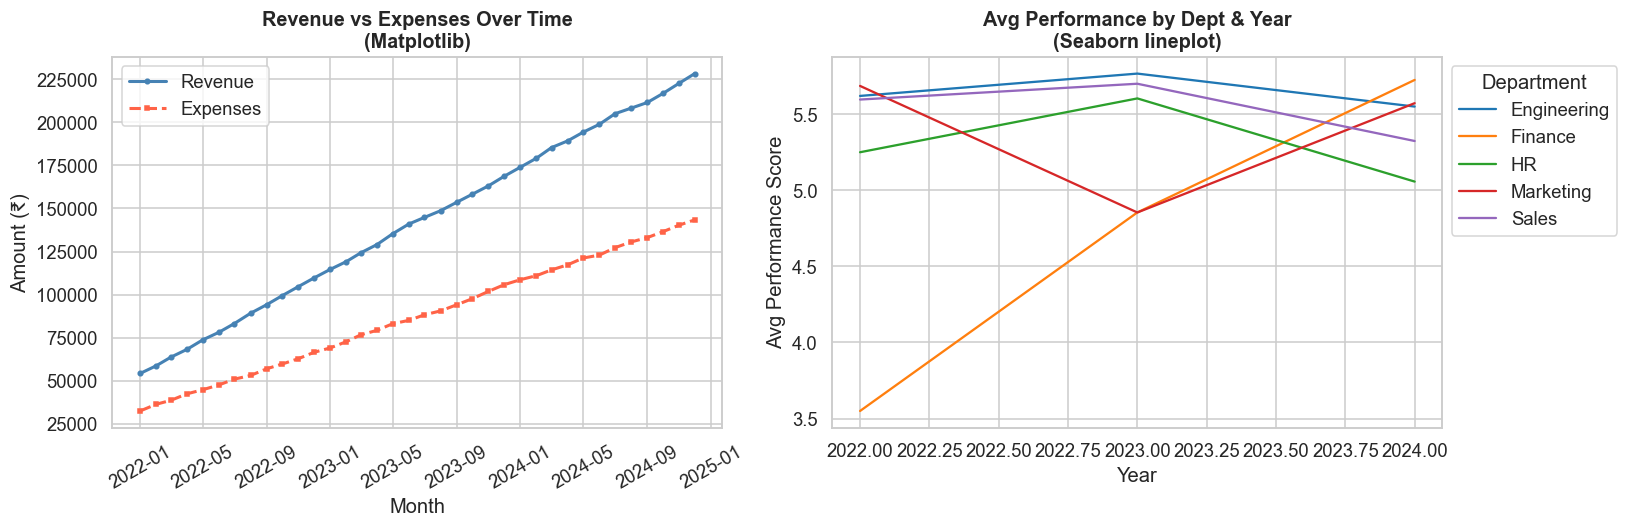

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: Matplotlib line chart ---
axes[0].plot(ts['Month'], ts['Revenue'],
             color='steelblue', linewidth=2, label='Revenue', marker='o', markersize=3)
axes[0].plot(ts['Month'], ts['Expenses'],
             color='tomato',    linewidth=2, label='Expenses', linestyle='--', marker='s', markersize=3)
axes[0].set_title('Revenue vs Expenses Over Time\n(Matplotlib)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Amount (₹)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# --- Right: Seaborn lineplot — with confidence interval ---
# Aggregate avg performance per year per department
perf_trend = df.groupby(['Year', 'Department'])['Performance'].mean().reset_index()

sns.lineplot(
    data=perf_trend,
    x='Year', y='Performance',
    hue='Department',          # different line per department
    markers=True,
    palette='tab10',
    ax=axes[1]
)
axes[1].set_title('Avg Performance by Dept & Year\n(Seaborn lineplot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Performance Score')
axes[1].legend(title='Department', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

---
## 4. Area Chart
### 📌 Use when: Showing **volume/magnitude of change** over time; stacked = part-to-whole over time

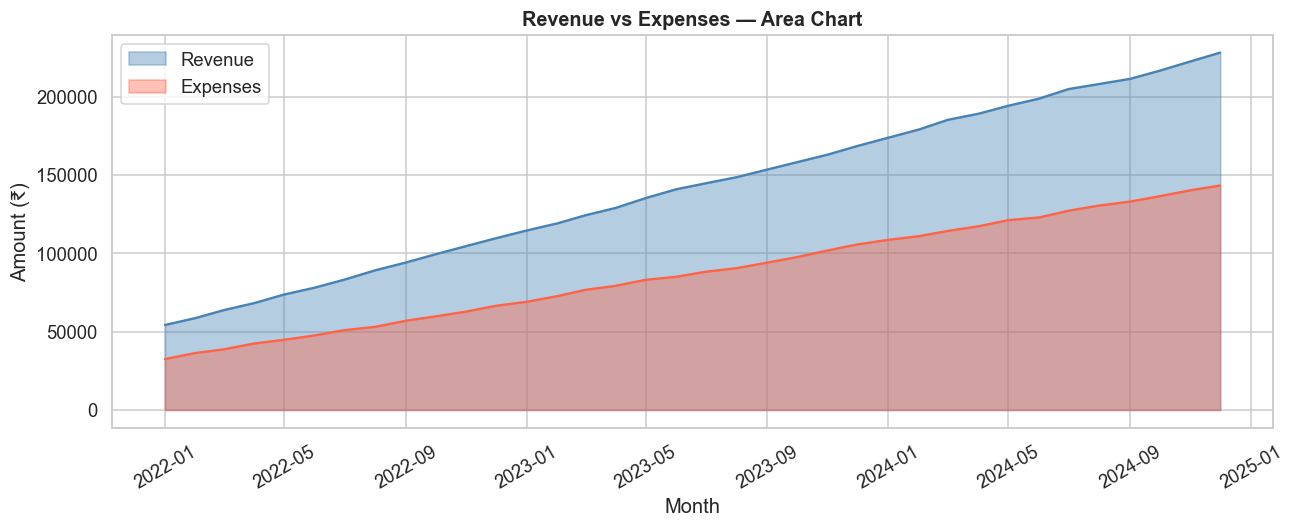

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

# fill_between fills area under the line
ax.fill_between(ts['Month'], ts['Revenue'],
                alpha=0.4, color='steelblue', label='Revenue')
ax.fill_between(ts['Month'], ts['Expenses'],
                alpha=0.4, color='tomato',    label='Expenses')

# Also draw the lines on top for clarity
ax.plot(ts['Month'], ts['Revenue'],  color='steelblue', linewidth=1.5)
ax.plot(ts['Month'], ts['Expenses'], color='tomato',    linewidth=1.5)

ax.set_title('Revenue vs Expenses — Area Chart', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount (₹)')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## 5. Histogram
### 📌 Use when: Understanding the **distribution** of a single continuous variable

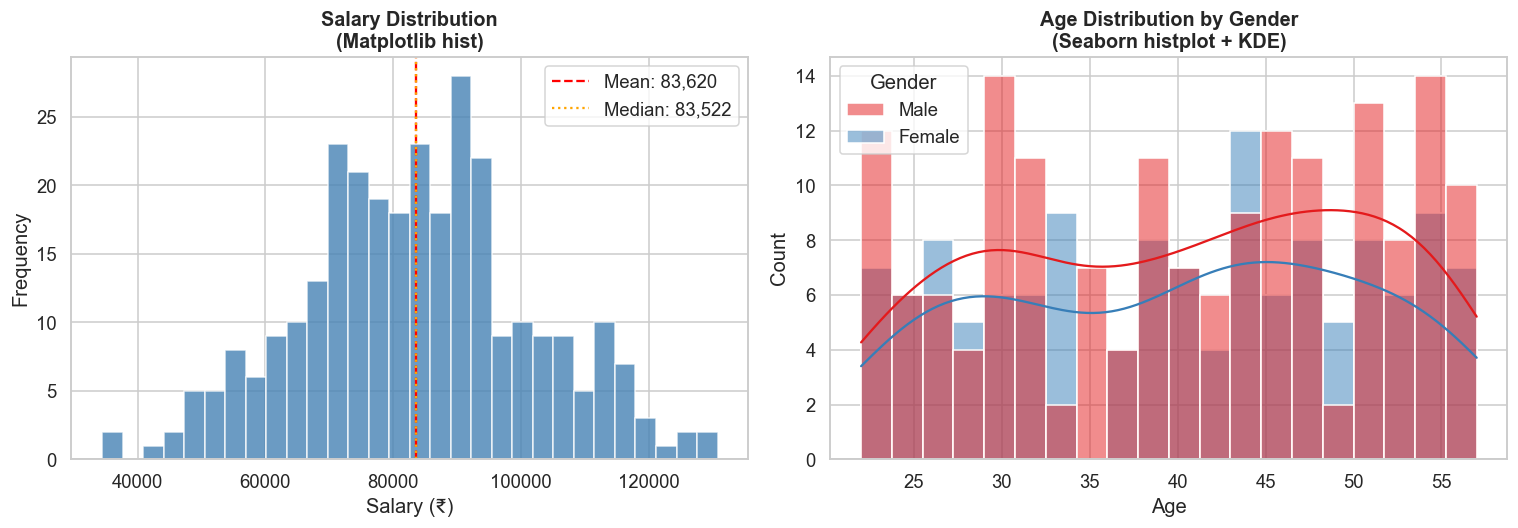

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Matplotlib histogram ---
axes[0].hist(
    df['Salary'],
    bins=30,                        # number of bins; more bins = more detail
    color='steelblue',
    edgecolor='white',
    alpha=0.8
)
axes[0].axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Mean: {df['Salary'].mean():,.0f}")
axes[0].axvline(df['Salary'].median(), color='orange', linestyle=':', label=f"Median: {df['Salary'].median():,.0f}")
axes[0].set_title('Salary Distribution\n(Matplotlib hist)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salary (₹)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# --- Right: Seaborn histplot with KDE overlay ---
sns.histplot(
    data=df,
    x='Age',
    bins=20,
    kde=True,           # kernel density estimate — smooth curve on top
    hue='Gender',       # separate distribution per gender
    palette='Set1',
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title('Age Distribution by Gender\n(Seaborn histplot + KDE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 6. KDE Plot (Kernel Density Estimate)
### 📌 Use when: Smoother alternative to histogram; comparing distributions of groups

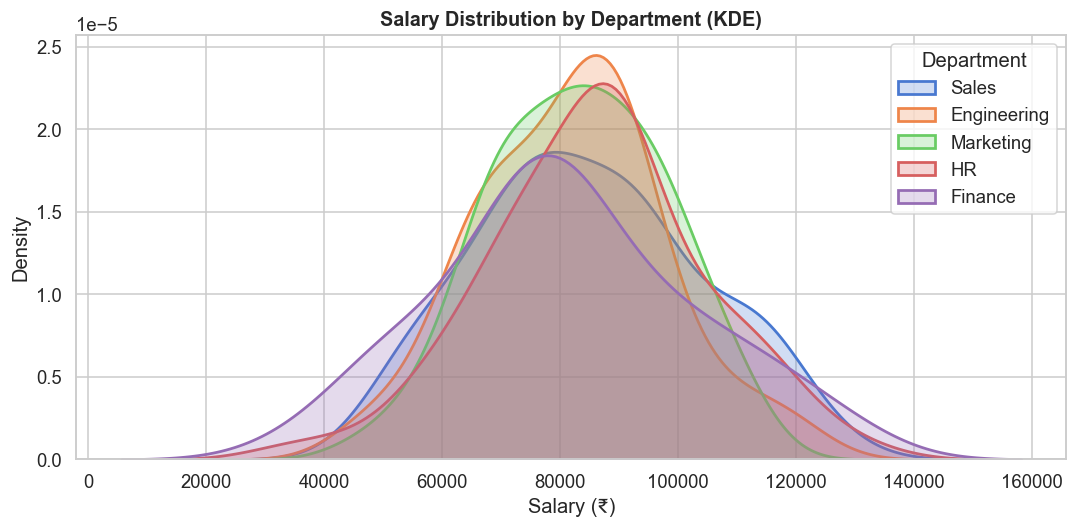

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

# kdeplot draws a smoothed probability density curve
for dept in departments:
    subset = df[df['Department'] == dept]['Salary']
    sns.kdeplot(
        data=subset,
        label=dept,
        fill=True,      # shade under the curve
        alpha=0.25,
        linewidth=1.8,
        ax=ax
    )

ax.set_title('Salary Distribution by Department (KDE)', fontsize=13, fontweight='bold')
ax.set_xlabel('Salary (₹)')
ax.set_ylabel('Density')
ax.legend(title='Department')
plt.tight_layout()
plt.show()

---
## 7. Box Plot
### 📌 Use when: Visualizing **median, IQR, and outliers** across groups

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25680\1119522170.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


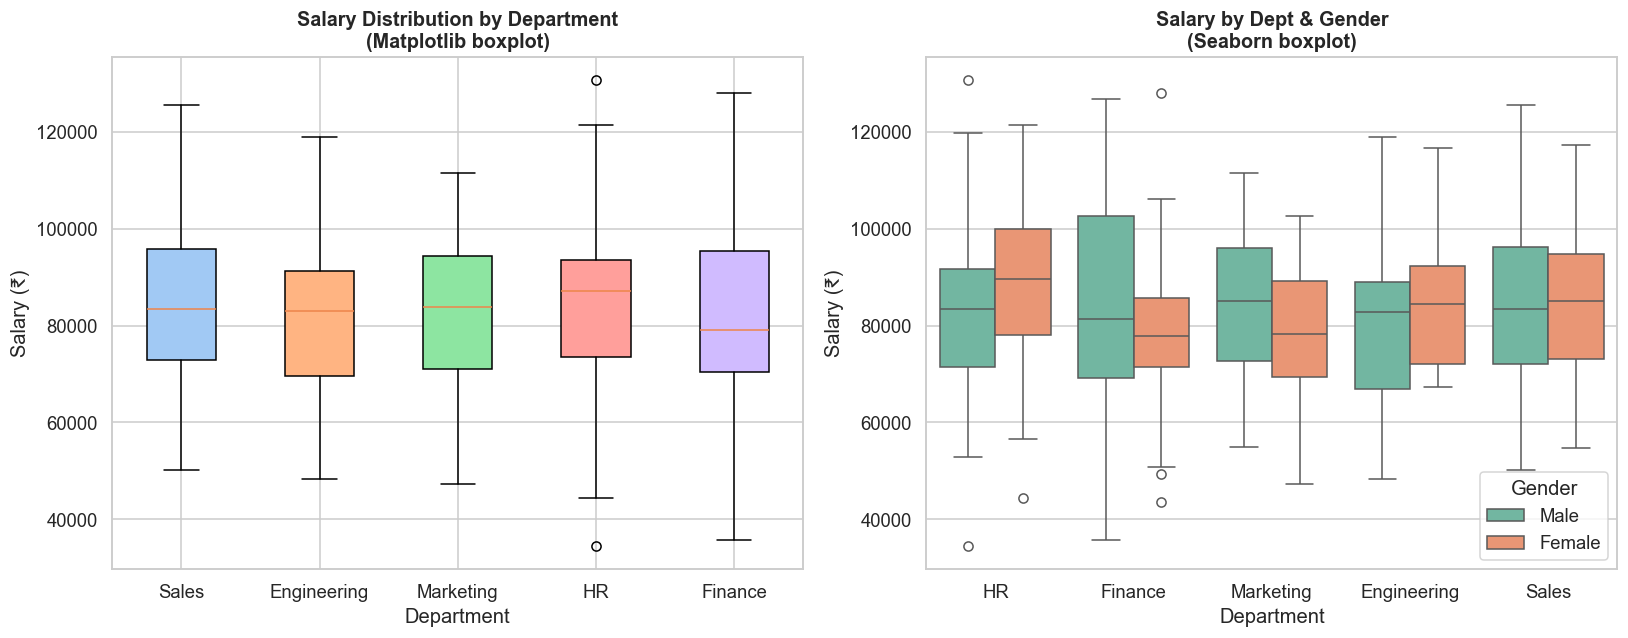

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Matplotlib boxplot ---
# Group salary data by department into a list of arrays
groups = [df[df['Department'] == d]['Salary'].values for d in departments]

bp = axes[0].boxplot(
    groups,
    labels=departments,
    patch_artist=True,         # fill boxes with color
    notch=False,               # notch=True shows CI around median
    showfliers=True            # show outliers as dots
)
# Color each box differently
colors = sns.color_palette('pastel', len(departments))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[0].set_title('Salary Distribution by Department\n(Matplotlib boxplot)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Salary (₹)')

# --- Right: Seaborn boxplot ---
sns.boxplot(
    data=df,
    x='Department',
    y='Salary',
    hue='Gender',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Salary by Dept & Gender\n(Seaborn boxplot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Salary (₹)')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

---
## 8. Violin Plot
### 📌 Use when: Box plot + distribution shape — shows where data is **dense vs sparse**

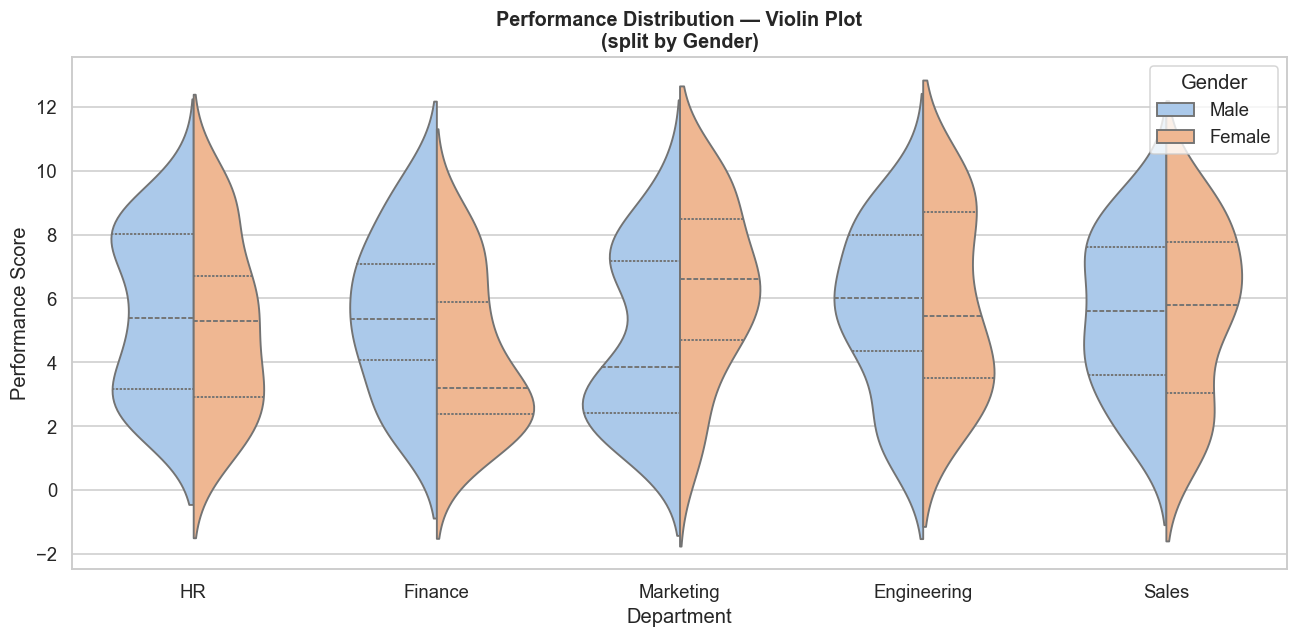

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

# Seaborn violinplot: combines KDE + boxplot
sns.violinplot(
    data=df,
    x='Department',
    y='Performance',
    hue='Gender',
    split=True,           # split=True mirrors male/female on each side of violin
    inner='quart',        # shows quartile lines inside the violin
    palette='pastel',
    ax=ax
)

ax.set_title('Performance Distribution — Violin Plot\n(split by Gender)', fontsize=13, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Performance Score')
ax.legend(title='Gender', loc='upper right')
plt.tight_layout()
plt.show()

---
## 9. Scatter Plot
### 📌 Use when: Exploring **relationship / correlation** between two continuous variables

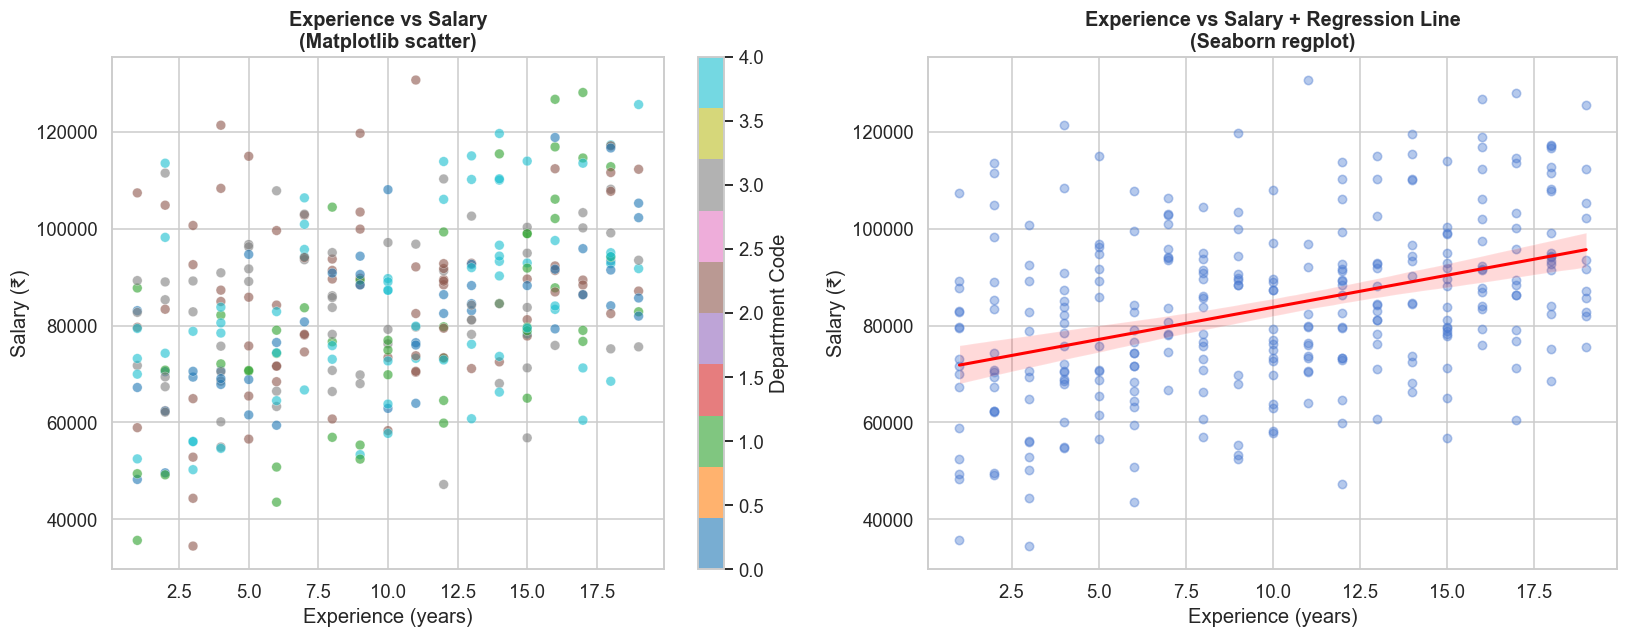

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Matplotlib scatter ---
# Color each department differently using a colormap
dept_codes = pd.Categorical(df['Department']).codes   # converts to numeric codes
scatter = axes[0].scatter(
    df['Experience'],
    df['Salary'],
    c=dept_codes,           # color = department code
    cmap='tab10',
    alpha=0.6,
    s=40,                   # marker size
    edgecolors='white', linewidths=0.3
)
axes[0].set_title('Experience vs Salary\n(Matplotlib scatter)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Experience (years)')
axes[0].set_ylabel('Salary (₹)')
plt.colorbar(scatter, ax=axes[0], label='Department Code')

# --- Right: Seaborn scatterplot with regression line ---
sns.regplot(
    data=df,
    x='Experience',
    y='Salary',
    scatter_kws={'alpha': 0.4, 's': 30},
    line_kws={'color': 'red', 'linewidth': 2},  # regression line in red
    ax=axes[1]
)
axes[1].set_title('Experience vs Salary + Regression Line\n(Seaborn regplot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Experience (years)')
axes[1].set_ylabel('Salary (₹)')

plt.tight_layout()
plt.show()

---
## 10. Bubble Chart
### 📌 Use when: Scatter plot but you want to encode a **3rd variable** via bubble size

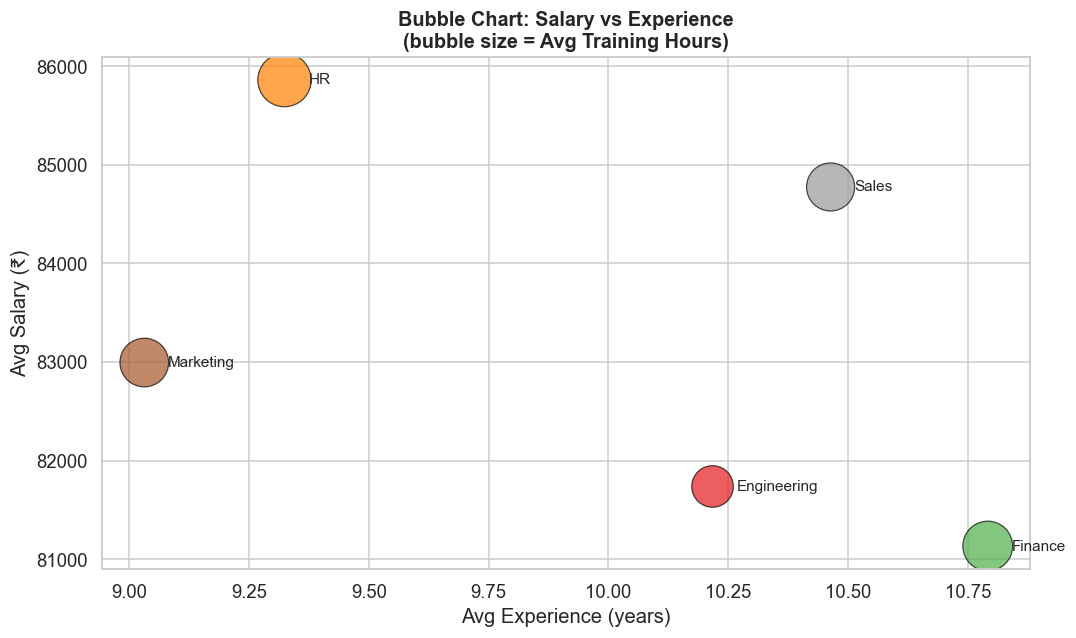

In [38]:
# Aggregate: mean salary, experience, and training hours per dept
bubble_data = df.groupby('Department').agg(
    Avg_Salary=('Salary', 'mean'),
    Avg_Experience=('Experience', 'mean'),
    Avg_Training=('Training_Hrs', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    bubble_data['Avg_Experience'],
    bubble_data['Avg_Salary'],
    s=bubble_data['Avg_Training'] * 50,   # bubble size ∝ training hours
    c=range(len(bubble_data)),
    cmap='Set1',
    alpha=0.7,
    edgecolors='black', linewidths=0.8
)

# Label each bubble with department name
for _, row in bubble_data.iterrows():
    ax.text(row['Avg_Experience'] + 0.05, row['Avg_Salary'],
            row['Department'], fontsize=10, va='center')

ax.set_title('Bubble Chart: Salary vs Experience\n(bubble size = Avg Training Hours)', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Experience (years)')
ax.set_ylabel('Avg Salary (₹)')
plt.tight_layout()
plt.show()

---
## 11. Pie & Donut Chart
### 📌 Use when: Showing **part-to-whole** composition (use sparingly; ≤5 slices)

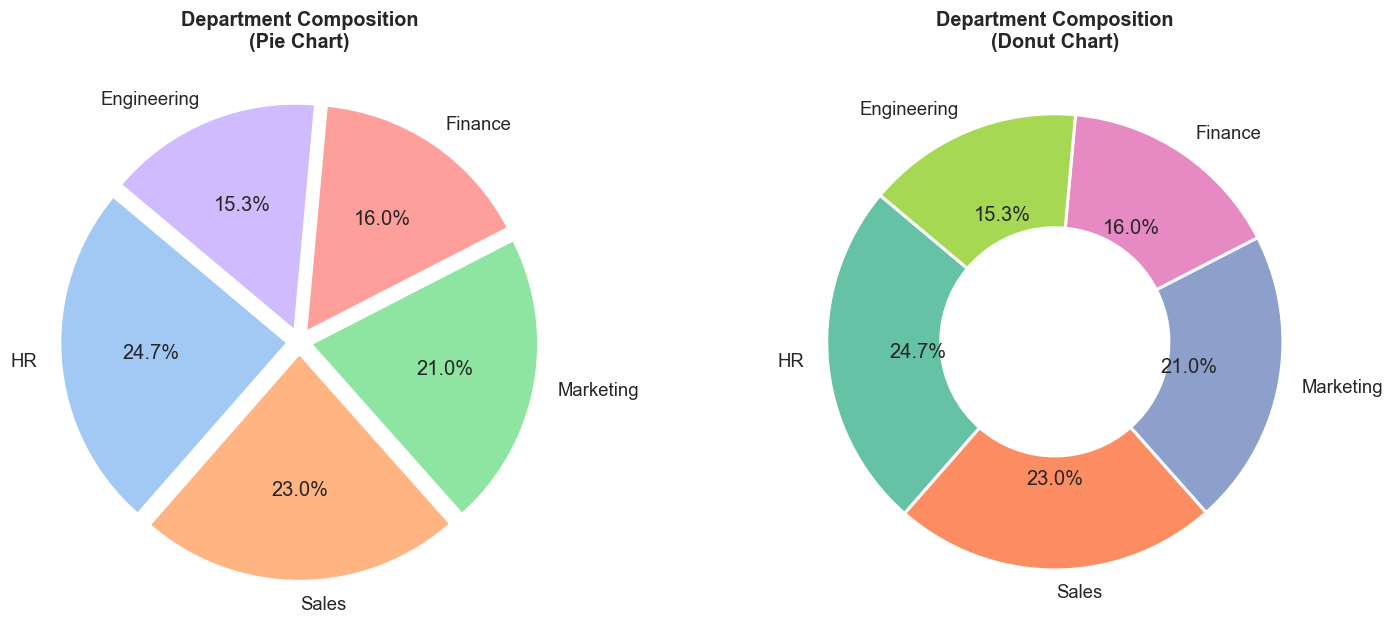

In [39]:
dept_count = df['Department'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Pie chart ---
wedge_props = dict(edgecolor='white', linewidth=2)
axes[0].pie(
    dept_count.values,
    labels=dept_count.index,
    autopct='%1.1f%%',          # show % inside slices
    startangle=140,             # rotate start
    explode=[0.05]*len(dept_count),   # slightly explode all slices
    colors=sns.color_palette('pastel'),
    wedgeprops=wedge_props
)
axes[0].set_title('Department Composition\n(Pie Chart)', fontsize=13, fontweight='bold')

# --- Right: Donut chart (pie with a white center circle) ---
axes[1].pie(
    dept_count.values,
    labels=dept_count.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2'),
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)  # width<1 = donut hole
)
axes[1].set_title('Department Composition\n(Donut Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 12. Heatmap
### 📌 Use when: Visualizing a **correlation matrix** or 2D grid of values (row × column)

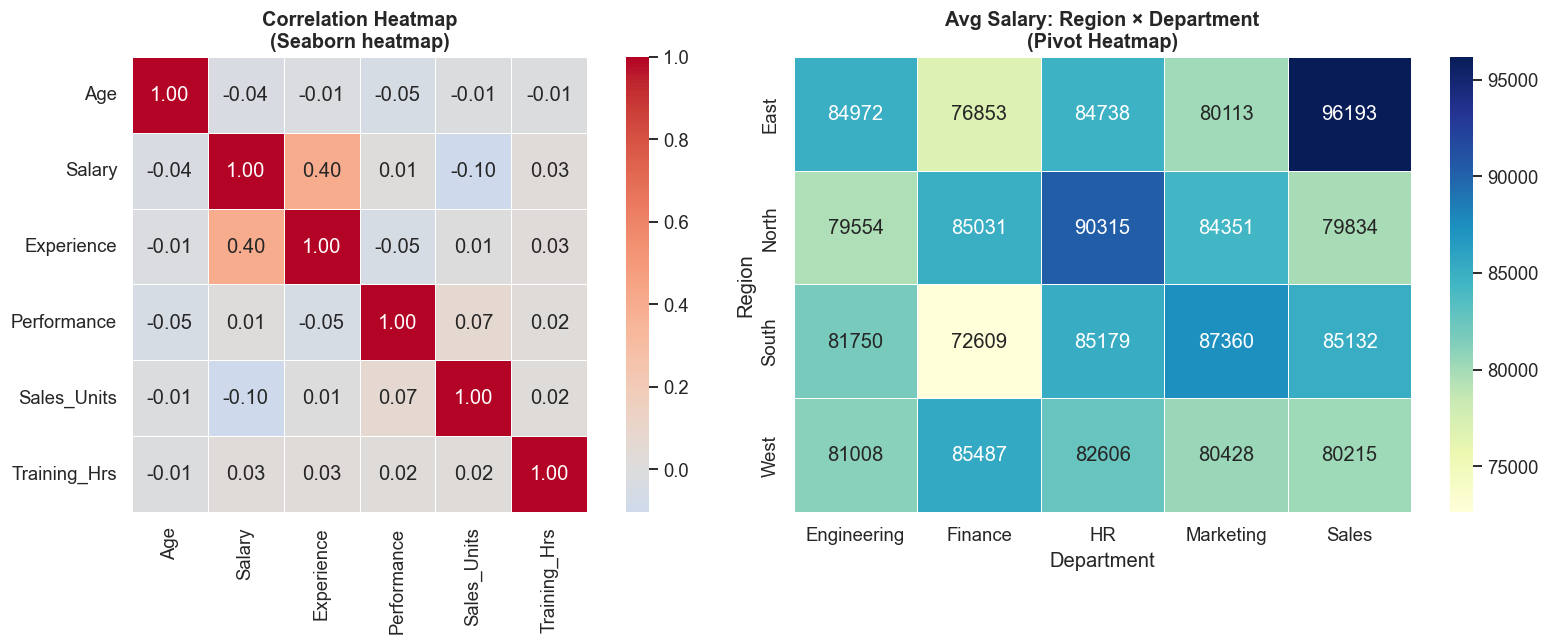

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Correlation heatmap ---
numeric_cols = ['Age', 'Salary', 'Experience', 'Performance', 'Sales_Units', 'Training_Hrs']
corr_matrix = df[numeric_cols].corr()   # pairwise Pearson correlations

sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values in cells
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # red=positive, blue=negative
    center=0,            # center colormap at 0
    linewidths=0.5,
    square=True,
    ax=axes[0]
)
axes[0].set_title('Correlation Heatmap\n(Seaborn heatmap)', fontsize=13, fontweight='bold')

# --- Right: Pivot table heatmap — Avg Salary per Region & Department ---
pivot = df.pivot_table(values='Salary', index='Region', columns='Department', aggfunc='mean')

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Avg Salary: Region × Department\n(Pivot Heatmap)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 13. Pair Plot
### 📌 Use when: Quickly exploring **all pairwise relationships** in a dataset (EDA)

---
## 14. Stacked Bar Chart
### 📌 Use when: Comparing **part-to-whole** across categories simultaneously

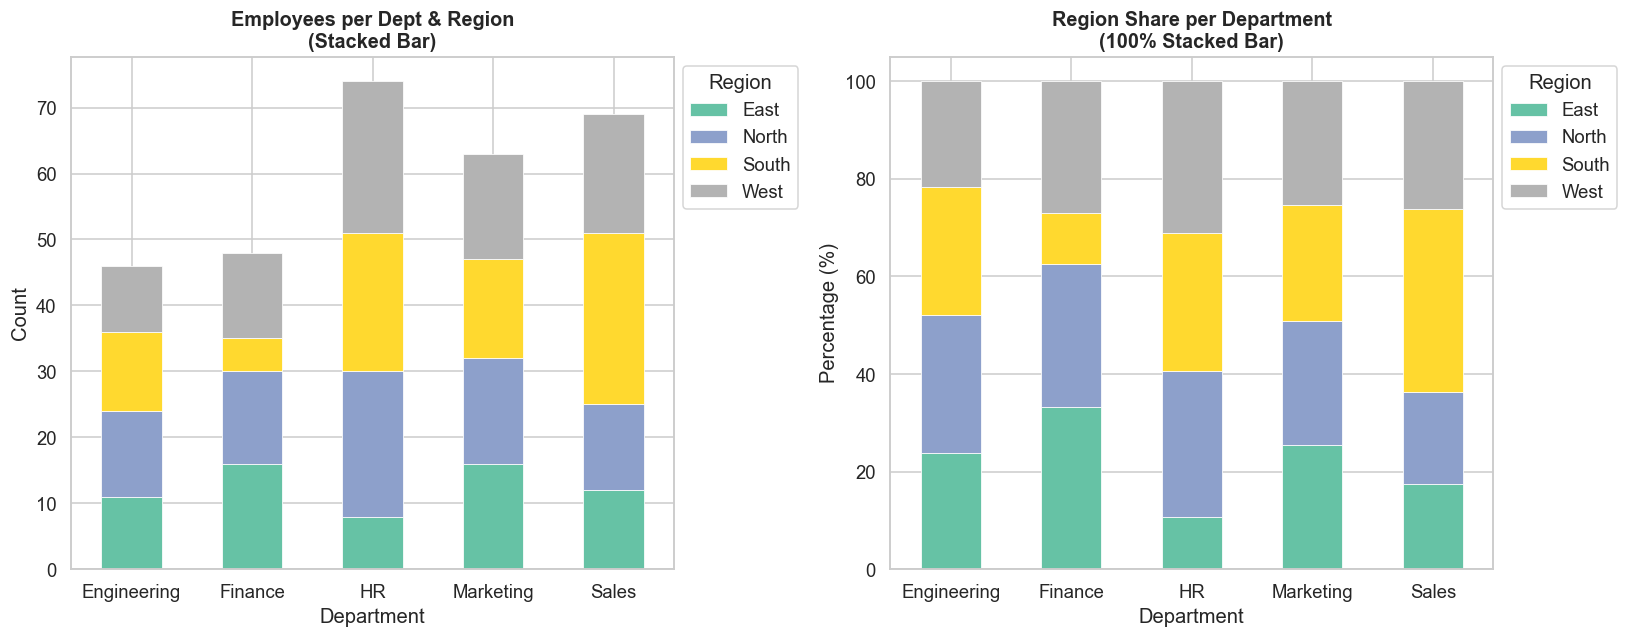

In [41]:
# Count employees by Department AND Region
stacked_data = df.groupby(['Department', 'Region']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Stacked bar ---
stacked_data.plot(
    kind='bar',
    stacked=True,           # stacked=True → segments stacked on each other
    ax=axes[0],
    colormap='Set2',
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_title('Employees per Dept & Region\n(Stacked Bar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Region', bbox_to_anchor=(1, 1))

# --- Right: 100% Stacked (normalized) ---
stacked_pct = stacked_data.div(stacked_data.sum(axis=1), axis=0) * 100  # normalize to %

stacked_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    colormap='Set2',
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title('Region Share per Department\n(100% Stacked Bar)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Region', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

---
## 15. Strip Plot & Swarm Plot
### 📌 Use when: Show ALL individual data points along a categorical axis (no overlap in swarm)

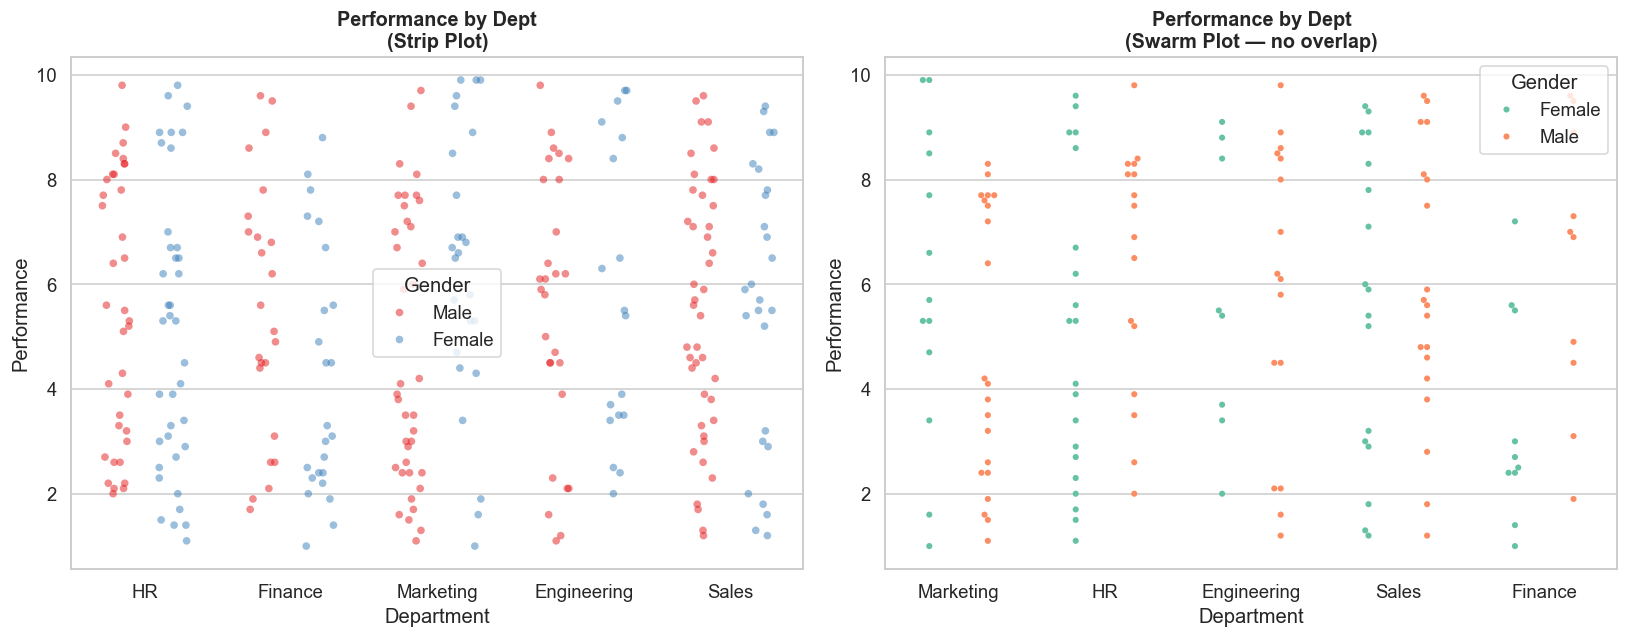

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Strip plot (points may overlap) ---
sns.stripplot(
    data=df,
    x='Department', y='Performance',
    hue='Gender',
    dodge=True,          # separate male/female horizontally
    jitter=0.2,          # add random horizontal noise to avoid overlap
    alpha=0.5,
    palette='Set1',
    ax=axes[0]
)
axes[0].set_title('Performance by Dept\n(Strip Plot)', fontsize=13, fontweight='bold')
axes[0].legend(title='Gender')

# --- Right: Swarm plot (no overlap — beeswarm layout) ---
# Note: swarmplot can be slow for large N; sample 150 rows
sample = df.sample(150, random_state=1)
sns.swarmplot(
    data=sample,
    x='Department', y='Performance',
    hue='Gender',
    dodge=True,
    palette='Set2',
    size=4,
    ax=axes[1]
)
axes[1].set_title('Performance by Dept\n(Swarm Plot — no overlap)', fontsize=13, fontweight='bold')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

---
## 16. Stacked Area Chart
### 📌 Use when: Part-to-whole **over time** — how categories contribute to a total

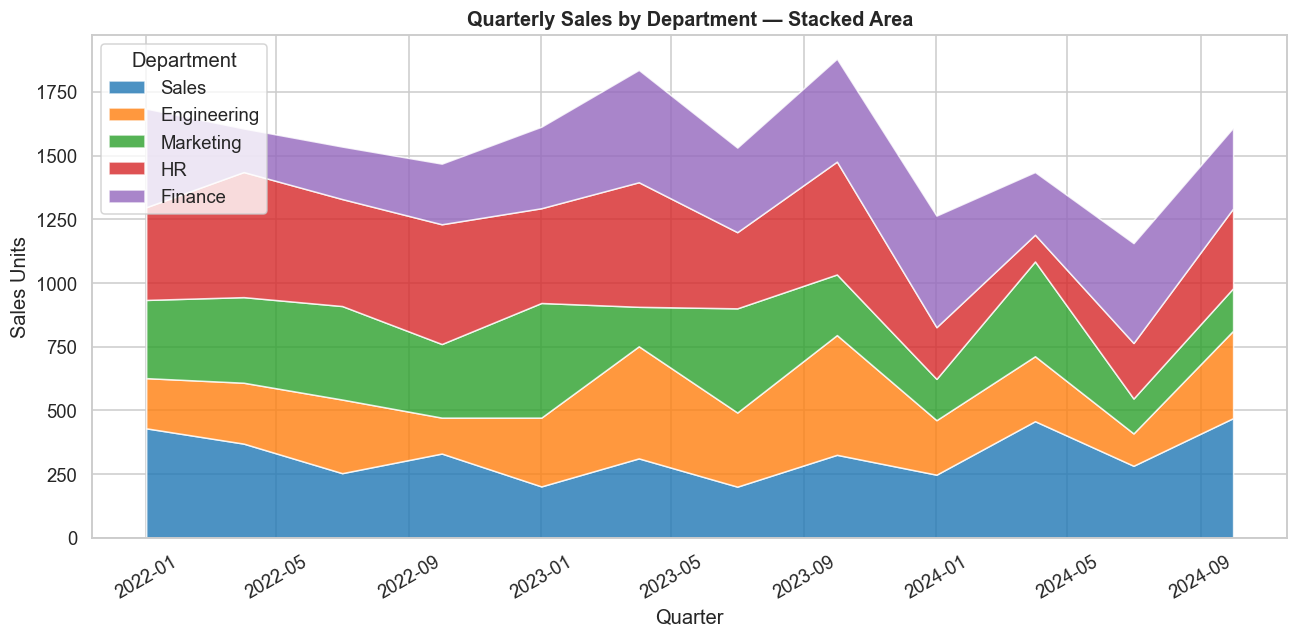

In [43]:
# Simulate quarterly sales by department
quarters = pd.date_range('2022-Q1', periods=12, freq='QS')
sales_ts = pd.DataFrame(
    np.random.randint(100, 500, (12, 5)),
    index=quarters,
    columns=departments
)

fig, ax = plt.subplots(figsize=(12, 6))

# stackplot: each area is stacked on the previous one
ax.stackplot(
    sales_ts.index,
    [sales_ts[col] for col in departments],
    labels=departments,
    alpha=0.8,
    colors=sns.color_palette('tab10', len(departments))
)

ax.set_title('Quarterly Sales by Department — Stacked Area', fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Sales Units')
ax.legend(loc='upper left', title='Department')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## 17. Facet Grid (Small Multiples)
### 📌 Use when: Comparing same chart across **multiple subgroups** simultaneously

---
## 18. Joint Plot
### 📌 Use when: Scatter plot + marginal distributions of BOTH axes at the same time

---
## 19. Radar / Spider Chart
### 📌 Use when: Comparing **multiple attributes** of one or more entities on a web

---
## 20. Waterfall Chart
### 📌 Use when: Showing how values **incrementally add/subtract** to reach a total (financial data)

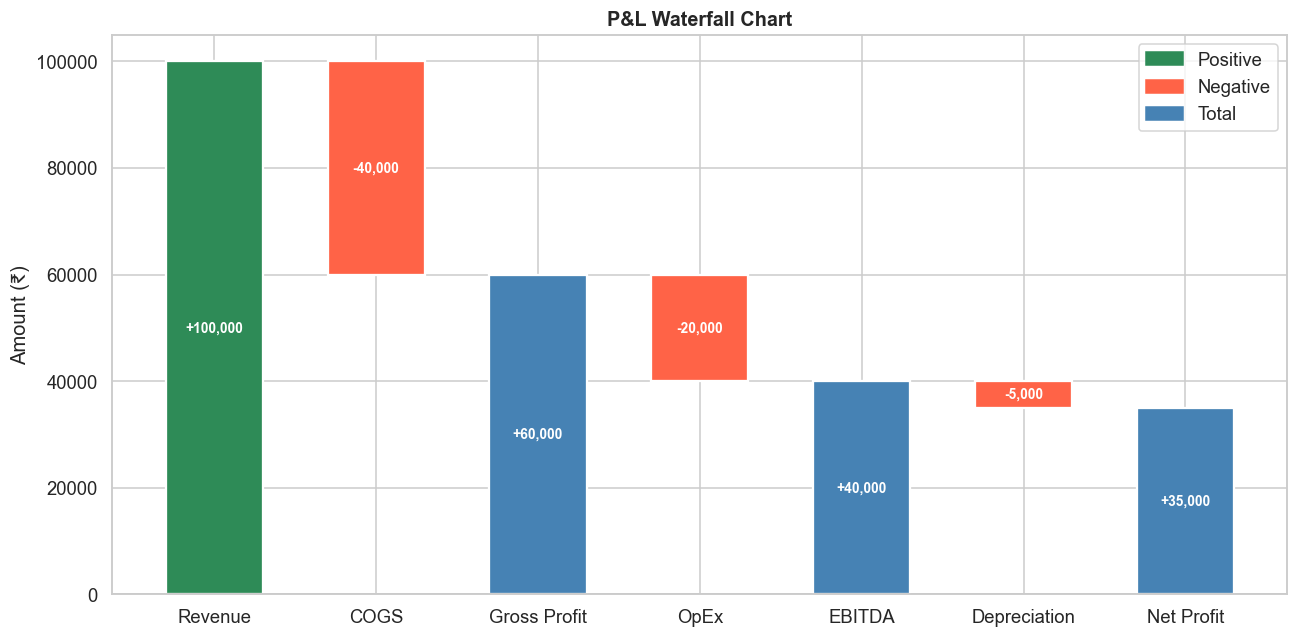

In [44]:
# Simulate a P&L waterfall
items   = ['Revenue', 'COGS',   'Gross Profit', 'OpEx',   'EBITDA', 'Depreciation', 'Net Profit']
values  = [100000,    -40000,    60000,          -20000,   40000,    -5000,           35000]
is_total = [False,    False,     True,           False,    True,     False,           True]  # totals shown differently

fig, ax = plt.subplots(figsize=(12, 6))

running_total = 0
bottoms = []

for i, (item, val, total) in enumerate(zip(items, values, is_total)):
    if total:
        bottom = 0          # totals start from 0
        color = 'steelblue'
    else:
        bottom = running_total if val > 0 else running_total + val
        color = 'seagreen' if val > 0 else 'tomato'   # green=positive, red=negative

    ax.bar(item, abs(val), bottom=bottom, color=color, edgecolor='white', linewidth=1.5, width=0.6)

    # Value label above/inside bar
    label_y = bottom + abs(val) / 2
    ax.text(i, label_y, f'{val:+,.0f}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    if not total:
        running_total += val
    else:
        running_total = val

ax.set_title('P&L Waterfall Chart', fontsize=13, fontweight='bold')
ax.set_ylabel('Amount (₹)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')

# Legend
ax.legend(handles=[
    mpatches.Patch(color='seagreen', label='Positive'),
    mpatches.Patch(color='tomato',   label='Negative'),
    mpatches.Patch(color='steelblue', label='Total')
])
plt.tight_layout()
plt.show()

---
## 21. Lollipop Chart
### 📌 Use when: Cleaner alternative to bar chart; great for **ranking** with less visual clutter

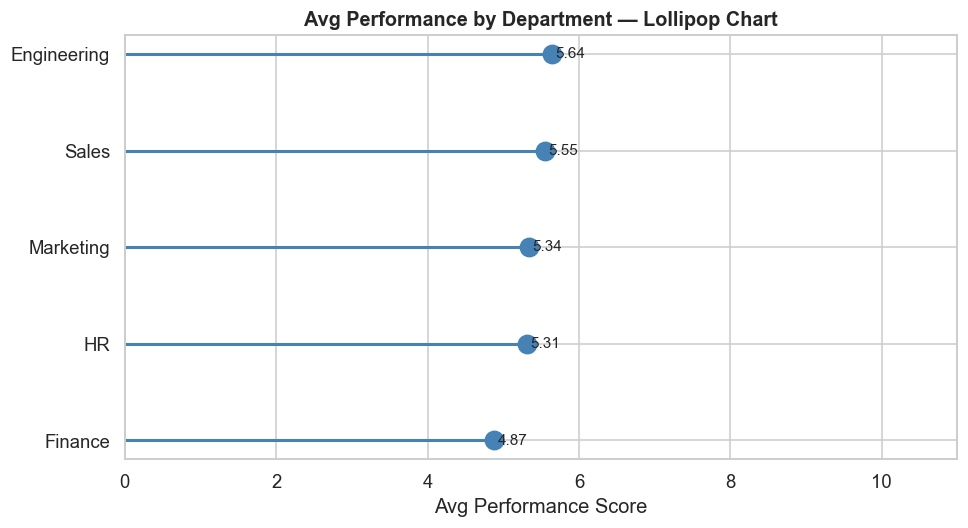

In [45]:
avg_perf = df.groupby('Department')['Performance'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

# Horizontal lines (the stick)
ax.hlines(y=avg_perf.index, xmin=0, xmax=avg_perf.values,
          colors='steelblue', linewidth=2)

# Dots at the end (the lollipop)
ax.plot(avg_perf.values, avg_perf.index,
        'o', color='steelblue', markersize=12, zorder=3)

# Value labels
for dept, val in avg_perf.items():
    ax.text(val + 0.05, dept, f'{val:.2f}', va='center', fontsize=10)

ax.set_title('Avg Performance by Department — Lollipop Chart', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Performance Score')
ax.set_xlim(0, 11)
plt.tight_layout()
plt.show()

---
## 22. Error Bar Chart
### 📌 Use when: Showing **mean ± variability** (std dev or confidence interval) per group

---
## 23. 2D Histogram / Hexbin Plot
### 📌 Use when: Scatter plot with too many points (overplotting) — density shown by color

---
## 24. Subplots Dashboard (putting it all together)
### 📌 GridSpec: complex multi-panel figure with unequal subplot sizes

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25680\1651094318.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Performance',
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


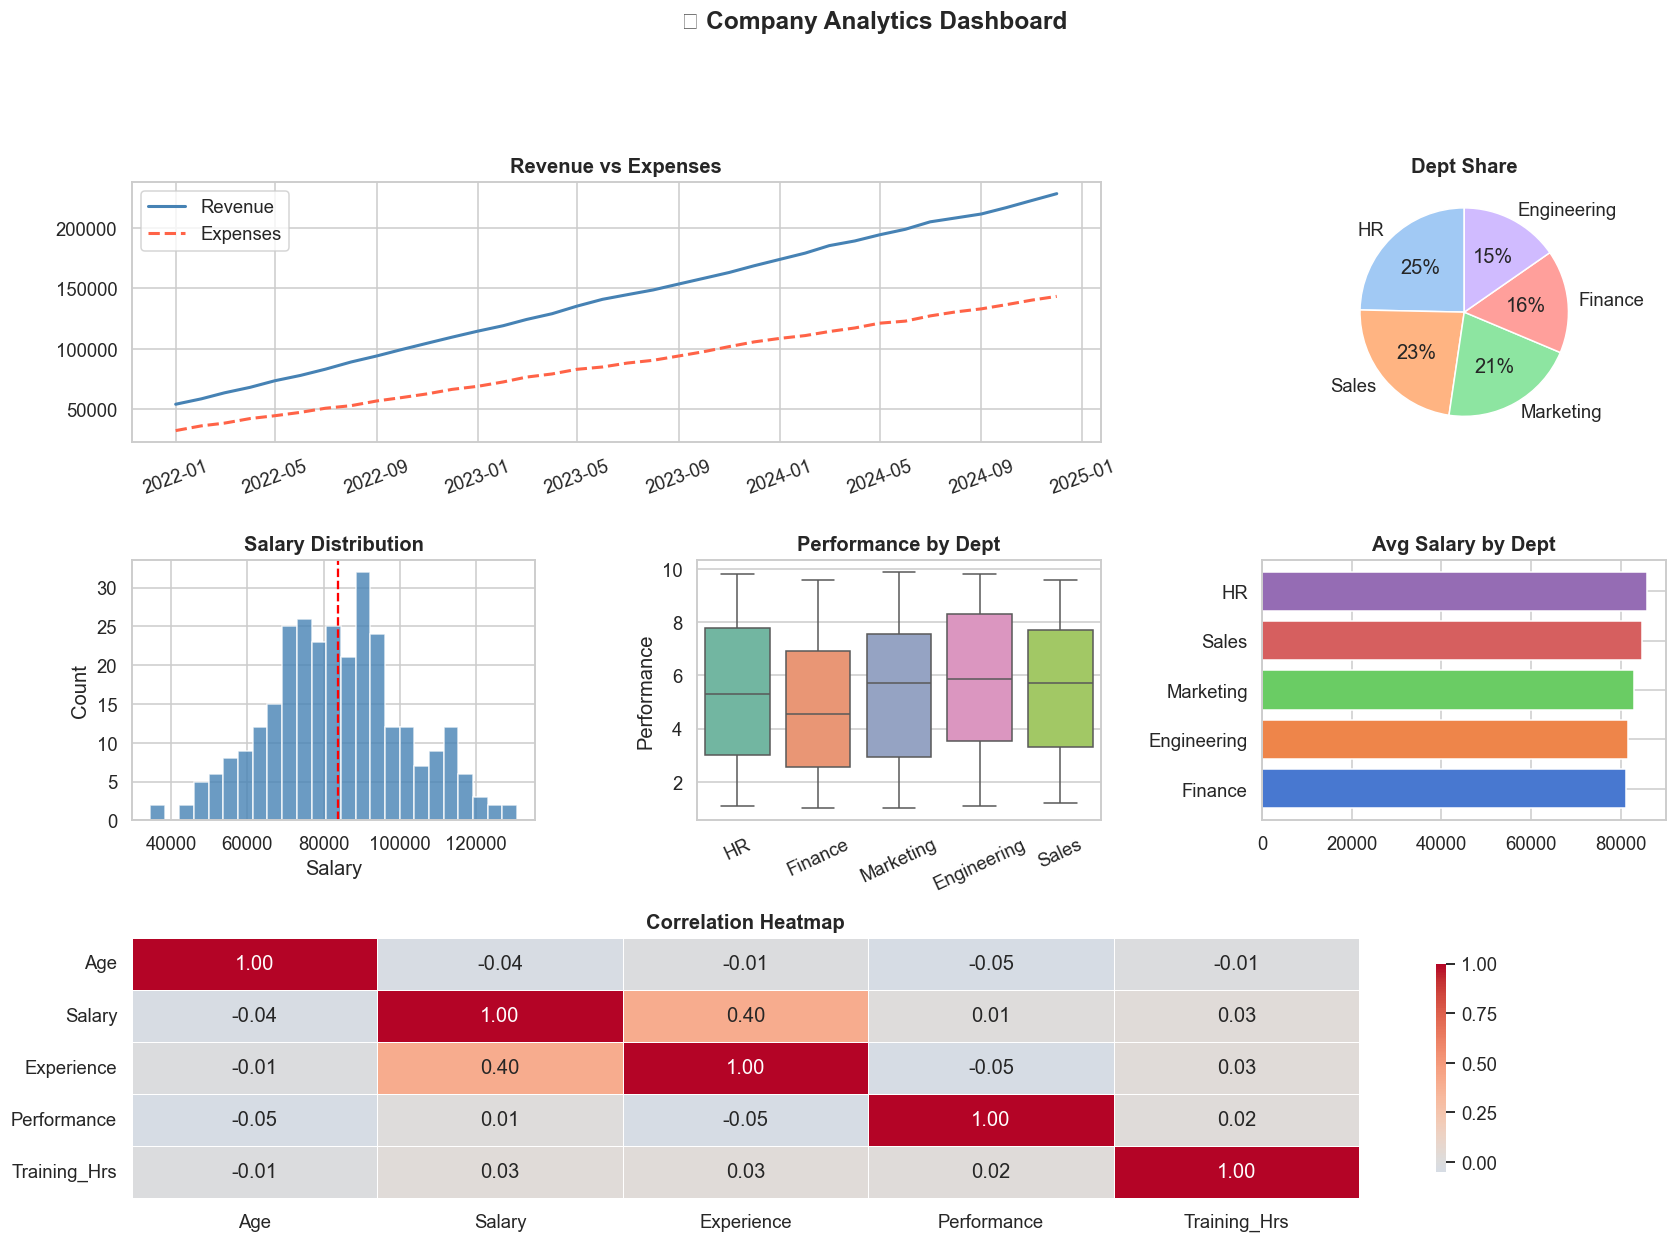

In [46]:
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.4)

# --- Top-left (wide): Line chart ---
ax1 = fig.add_subplot(gs[0, :2])   # spans 2 columns
ax1.plot(ts['Month'], ts['Revenue'], color='steelblue', lw=2, label='Revenue')
ax1.plot(ts['Month'], ts['Expenses'], color='tomato', lw=2, linestyle='--', label='Expenses')
ax1.set_title('Revenue vs Expenses', fontweight='bold')
ax1.legend(); ax1.tick_params(axis='x', rotation=20)

# --- Top-right: Pie chart ---
ax2 = fig.add_subplot(gs[0, 2])
dept_c = df['Department'].value_counts()
ax2.pie(dept_c, labels=dept_c.index, autopct='%1.0f%%',
        colors=sns.color_palette('pastel'), startangle=90,
        wedgeprops=dict(edgecolor='white'))
ax2.set_title('Dept Share', fontweight='bold')

# --- Middle-left: Histogram ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df['Salary'], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
ax3.axvline(df['Salary'].mean(), color='red', linestyle='--')
ax3.set_title('Salary Distribution', fontweight='bold')
ax3.set_xlabel('Salary'); ax3.set_ylabel('Count')

# --- Middle-center: Box plot ---
ax4 = fig.add_subplot(gs[1, 1])
sns.boxplot(data=df, x='Department', y='Performance',
            palette='Set2', ax=ax4)
ax4.set_title('Performance by Dept', fontweight='bold')
ax4.set_xlabel(''); ax4.tick_params(axis='x', rotation=25)

# --- Middle-right: Bar chart ---
ax5 = fig.add_subplot(gs[1, 2])
avg_sal = df.groupby('Department')['Salary'].mean().sort_values()
ax5.barh(avg_sal.index, avg_sal.values,
         color=sns.color_palette('muted', len(avg_sal)))
ax5.set_title('Avg Salary by Dept', fontweight='bold')

# --- Bottom: Heatmap (spanning all 3 cols) ---
ax6 = fig.add_subplot(gs[2, :])
corr = df[['Age','Salary','Experience','Performance','Training_Hrs']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax6, cbar_kws={'shrink': 0.8})
ax6.set_title('Correlation Heatmap', fontweight='bold')

fig.suptitle('📊 Company Analytics Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.show()

---
## 📋 Quick Reference: When to Use Which Chart

| Chart | Use When | Library |
|---|---|---|
| **Bar Chart** | Compare categories (count/avg) | Both |
| **Horizontal Bar** | Long category labels / ranking | Both |
| **Stacked Bar** | Part-to-whole across categories | Both |
| **Lollipop** | Clean ranking, less clutter | Matplotlib |
| **Line Chart** | Trend over time (continuous) | Both |
| **Area Chart** | Volume of change over time | Both |
| **Stacked Area** | Part-to-whole over time | Matplotlib |
| **Pie / Donut** | Composition (≤5 categories) | Matplotlib |
| **Histogram** | Distribution of 1 continuous variable | Both |
| **KDE Plot** | Smoothed distribution / compare groups | Seaborn |
| **Box Plot** | Median, IQR, outliers per group | Both |
| **Violin Plot** | Box + distribution shape | Seaborn |
| **Strip / Swarm** | All raw data points per category | Seaborn |
| **Scatter Plot** | Correlation between 2 continuous vars | Both |
| **Bubble Chart** | Scatter + encode 3rd variable via size | Matplotlib |
| **Hexbin / 2D KDE** | Dense scatter (overplotting) | Both |
| **Heatmap** | 2D matrix — correlation or pivot table | Seaborn |
| **Pair Plot** | All pairwise relationships (EDA) | Seaborn |
| **Facet Grid** | Same chart across multiple subgroups | Seaborn |
| **Joint Plot** | Scatter + marginal distributions | Seaborn |
| **Radar/Spider** | Multi-attribute comparison per entity | Matplotlib |
| **Waterfall** | Incremental additions/subtractions | Matplotlib |
| **Error Bar** | Mean ± confidence interval per group | Both |
